<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/CNN/MODEL1_DEMO.v2Lucas(shreya_vers)withclassify_OF_TEST_CNN_Example_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cuda



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [7]:
def train_classifier(model, train_loader, test_loader=None, epochs=5,
                     learning_rate=1e-3, verbose=True):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-2) # Increased weight_decay
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=1, eta_min=1e-5
)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct    = 0
        total      = 0

        # Change your DataLoader loop inside train_classifier to unpack three items:
        for X_batch, demog_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            demog_batch = demog_batch.to(device)
            y_batch = y_batch.to(device)

            # Augmentations (Only apply noise/scaling to time-series data, not demographics!)
            X_batch = X_batch + 0.05 * torch.randn_like(X_batch)
            X_batch = X_batch * (0.8 + 0.4 * torch.rand(1, device=device))

            optimizer.zero_grad()

            # Pass both inputs to the fusion model
            logits = model(X_batch, demog_batch)


            loss = criterion(logits, y_batch)
            loss.backward() # Backpropagation
            optimizer.step() # Optimizer step

            b = X_batch.shape[0] # Get batch size
            total_loss += loss.item() * b
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total += b # Accumulate total samples processed

        scheduler.step()

        train_loss = total_loss / total
        train_acc  = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)
            if verbose:
                print(
                    f"Epoch {epoch+1}/{epochs}: "
                    f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
                    f"test loss={test_loss:.4f}, test acc={test_acc:.4f}, "
                    f"lr={optimizer.param_groups[0]['lr']:.2e}"
                )
        else:
            if verbose:
                print(
                    f"Epoch {epoch+1}/{epochs}: "
                    f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
                    f"lr={optimizer.param_groups[0]['lr']:.2e}"
                )

    return history


def evaluate_classifier(model, data_loader, criterion=None):
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, demog_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            demog_batch = demog_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch, demog_batch)
            loss = criterion(logits, y_batch)

            b = X_batch.shape[0]
            total_loss += loss.item() * b
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total += b

    return total_loss / total, correct / total



## 4. Helper Function: Plot Training Curves


In [8]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()



# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D CNN can be applied to sequential data such as:

- sensor measurements,
- financial signals,
- ECG or EEG recordings,
- audio waveforms,
- machine monitoring data,
- traffic or demand data.

A 1D convolutional layer slides filters along the time axis.

For PyTorch `nn.Conv1d`, the input shape is:

\[
N \times C \times L,
\]

where:

- `N` is the batch size,
- `C` is the number of input channels,
- `L` is the sequence length.

For a single univariate time series, `C = 1`.



## 10. Generate a Synthetic Time-Series Dataset

We will create a three-class time-series classification problem.

Each signal has length 100.

The classes are:

- Class 0: low-frequency sine wave,
- Class 1: high-frequency sine wave,
- Class 2: square-wave-like signal.

Noise is added so the classification task is not completely trivial.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [10]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/REU ECG Analysis
ECG_metrics_1K.npy  ECG_waveforms_1K.npy  EchoNext_EchoData_5K.csv


In [11]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

#labels
labels = Echo_5K['shd_moderate_or_greater_flag']
negative = labels==0
positive = labels==1


#initial definitions - ECGs
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


#initial definitions - metrics
y_metric = np.array(labels[:1000])
demog_metric = Echo_5K[['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']]
demog_metric = np.array(demog_metric[:1000])
print(demog_metric[50])


(1000, 12, 2500)
(1000,)
[64 'male' 'white' 77 77.0 156.0 76 405]



## 11. Visualize Example Time Series


In [12]:

'''
plt.figure(figsize=(10, 5))
for class_label in range(3):
    idx = np.where(y_ts == class_label)[0][0]
    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")

plt.xlabel("Time")
plt.ylabel("Signal value")
plt.title("Example Time Series from Each Class")
plt.grid(True)
plt.legend()
plt.show()
'''


'\nplt.figure(figsize=(10, 5))\nfor class_label in range(3):\n    idx = np.where(y_ts == class_label)[0][0]\n    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")\n\nplt.xlabel("Time")\nplt.ylabel("Signal value")\nplt.title("Example Time Series from Each Class")\nplt.grid(True)\nplt.legend()\nplt.show()\n'


## 12. Create PyTorch DataLoaders for Time Series


In [13]:

'''
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32, device = device)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long, device = device)


ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))
'''


'\nX_ts_tensor = torch.tensor(X_ts, dtype=torch.float32, device = device)\ny_ts_tensor = torch.tensor(y_ts, dtype=torch.long, device = device)\n\n\nts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)\n\ntrain_size = int(0.8 * len(ts_dataset))\ntest_size = len(ts_dataset) - train_size\n\nts_train_dataset, ts_test_dataset = random_split(\n    ts_dataset,\n    [train_size, test_size],\n    generator=torch.Generator().manual_seed(42)\n)\n\nts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size\nbatch = next(iter(ts_train_loader))\nprint(batch[0].shape)\n\nts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)\n\nprint("Time-series training samples:", len(ts_train_dataset))\nprint("Time-series test samples:", len(ts_test_dataset))\n'

In [14]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# =====================================================================
# 1. PREPROCESSING THE DEMOGRAPHIC DATA
# =====================================================================

# Convert your raw demographic array/list into a clean Pandas DataFrame
columns = ['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']
df_demog = pd.DataFrame(demog_metric, columns=columns)

# One-hot encode the categorical text features ('gender' and 'race')
# dummy_na=True ensures missing strings get their own column for the imputer to see
df_encoded = pd.get_dummies(df_demog, columns=['sex', 'race_ethnicity'], dummy_na=True, drop_first=False)

# All columns in df_encoded are now numerical and should be scaled before imputation.
# The previous `continuous_cols` list was incorrect because 'sex' and 'race_ethnicity'
# no longer exist after one-hot encoding.
scaler = StandardScaler()
# Apply scaler to all columns of the df_encoded DataFrame
df_encoded_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns, index=df_encoded.index) #ask

# Run KNN Imputer across the combined scaled and encoded columns
imputer = KNNImputer(n_neighbors=3) #looks at 3 other rows with similar data and takes their average for the missing value
demographic_clean = imputer.fit_transform(df_encoded_scaled)

# =====================================================================
# 2. PYTORCH TENSOR AND DATA LOADER SETUP
# =====================================================================

# Dynamically pull the exact number of features after one-hot encoding
fused_demog_dim = demographic_clean.shape[1] #ask
print(f"-> Dynamic Demographic Input Dimension: {fused_demog_dim}")

# Convert your underlying arrays straight into PyTorch device tensors
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32, device=device)
X_demog_tensor = torch.tensor(demographic_clean, dtype=torch.float32, device=device)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long, device=device)

# Zip all three parallel data structures into one Dataset
ts_dataset = TensorDataset(X_ts_tensor, X_demog_tensor, y_ts_tensor)

# Generate reproducible train/test splits
train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Build out your final multi-modal DataLoaders
ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True)
ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

-> Dynamic Demographic Input Dimension: 16



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [15]:
'''
class TimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — compress heavily with large kernel
            nn.Conv1d(in_channels, 4, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.AvgPool1d(kernel_size=5),   # 2500 → 500

            # Block 2 — compress again
            nn.Conv1d(4, 8,  kernel_size=9,  padding=4),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.AvgPool1d(kernel_size=5),   # 500 → 100

            # Block 3 — final compression
            nn.Conv1d(8, 12, kernel_size=5,  padding=2),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.AvgPool1d(kernel_size=5),   # 100 → 20

            # Block 4 — final compression
            nn.Conv1d(12, 16, kernel_size=3, padding=2),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.AvgPool1d(kernel_size=5),   # 20 → 4


        )
        with torch.no_grad():
            dummy        = torch.zeros(1, in_channels, sequence_length)
            dummy_out    = self.features(dummy)
            flattened_sz = dummy_out.shape[1] * dummy_out.shape[2]

        print(f"Flattened size after conv blocks: {flattened_sz}")

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_sz, 20),   # ← dynamic, never hardcoded
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(20, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


ts_model = TimeSeriesConvNet(sequence_length=2500, num_classes=2)
print(ts_model)
'''

'\nclass TimeSeriesConvNet(nn.Module):\n    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):\n        super().__init__()\n\n        self.features = nn.Sequential(\n            # Block 1 — compress heavily with large kernel\n            nn.Conv1d(in_channels, 4, kernel_size=15, padding=7),\n            nn.ReLU(),\n            nn.Dropout(0.20),\n            nn.AvgPool1d(kernel_size=5),   # 2500 → 500\n\n            # Block 2 — compress again\n            nn.Conv1d(4, 8,  kernel_size=9,  padding=4),\n            nn.ReLU(),\n            nn.Dropout(0.30),\n            nn.AvgPool1d(kernel_size=5),   # 500 → 100\n\n            # Block 3 — final compression\n            nn.Conv1d(8, 12, kernel_size=5,  padding=2),\n            nn.ReLU(),\n            nn.Dropout(0.30),\n            nn.AvgPool1d(kernel_size=5),   # 100 → 20\n\n            # Block 4 — final compression\n            nn.Conv1d(12, 16, kernel_size=3, padding=2),\n            nn.ReLU(),\n            nn.Dropout

In [16]:
import torch
import torch.nn as nn

class DemographicMLP(nn.Module): #MLP = multilayer perceptron ask
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32), # Added Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.3), # Increased dropout
            nn.Linear(32, output_dim),
            nn.BatchNorm1d(output_dim), # Added Batch Normalization
            nn.ReLU()
        )

    def forward(self, x):
        return self.mlp(x)


class LateFusionHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):
        super().__init__()

        # 1. Time Series Feature Extractor (Modified from your original TimeSeriesConvNet)
        self.ts_features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16), # Added Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.5), # Increased dropout
            nn.AdaptiveAvgPool1d(250),   # 2500 -> 250

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), # Added Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.6), # Increased dropout
            nn.AdaptiveAvgPool1d(25),   # 250 -> 25

            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), # Added Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.AdaptiveAvgPool1d(1),        # 25 -> 1
        )

        # 2. Demographic Feature Extractor
        self.demog_features = DemographicMLP(input_dim=demog_dim, output_dim=16)

        # 3. Final Fusion Classifier
        # Total features = 32 (from TimeSeries) + 16 (from MLP) = 48
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 + 16, num_classes)
        )

    def forward(self, ts_input, demog_input):
        # Extract features from both modalities
        ts_emb = self.ts_features(ts_input)
        ts_emb = torch.flatten(ts_emb, start_dim=1) # Shape: [Batch, 32]

        demog_emb = self.demog_features(demog_input) # Shape: [Batch, 16]

        # Late Fusion: Concatenate the feature vectors
        fused_features = torch.cat((ts_emb, demog_emb), dim=1) # Shape: [Batch, 48]

        # Classify
        logits = self.classifier(fused_features)
        return logits

# Instantiate the model
fusion_model = LateFusionHeartDiseaseModel(sequence_length=2500, num_classes=2)
print(fusion_model)


LateFusionHeartDiseaseModel(
  (ts_features): Sequential(
    (0): Conv1d(12, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): AdaptiveAvgPool1d(output_size=250)
    (5): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.6, inplace=False)
    (9): AdaptiveAvgPool1d(output_size=25)
    (10): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout(p=0.8, inplace=False)
    (14): AdaptiveAvgPool1d(output_size=1)
  )
  (demog_features): DemographicMLP(
    (mlp): Sequential(
      (0): Linear(in_features=8, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentu

In [17]:
print(next(fusion_model.parameters()).is_cuda)
unique, counts = torch.unique(y_ts_tensor, return_counts=True)
for cls, cnt in zip(unique.tolist(), counts.tolist()):
    print(f"Class {cls}: {cnt} samples ({cnt/len(y_ts_tensor)*100:.1f}%)")

False
Class 0: 477 samples (47.7%)
Class 1: 523 samples (52.3%)



## 14. Train the 1D CNN


Epoch 1/60: train loss=0.6667, train acc=0.5787, test loss=0.6635, test acc=0.6000, lr=9.94e-05
Epoch 2/60: train loss=0.6461, train acc=0.6125, test loss=0.6210, test acc=0.6900, lr=9.78e-05
Epoch 3/60: train loss=0.6464, train acc=0.6138, test loss=0.6043, test acc=0.7050, lr=9.51e-05
Epoch 4/60: train loss=0.6250, train acc=0.6350, test loss=0.5917, test acc=0.7150, lr=9.14e-05
Epoch 5/60: train loss=0.6252, train acc=0.6450, test loss=0.5765, test acc=0.7350, lr=8.68e-05
Epoch 6/60: train loss=0.6170, train acc=0.6550, test loss=0.5752, test acc=0.7250, lr=8.15e-05
Epoch 7/60: train loss=0.6076, train acc=0.6550, test loss=0.5639, test acc=0.7300, lr=7.54e-05
Epoch 8/60: train loss=0.6068, train acc=0.6525, test loss=0.5565, test acc=0.7350, lr=6.89e-05
Epoch 9/60: train loss=0.5943, train acc=0.6937, test loss=0.5482, test acc=0.7450, lr=6.20e-05
Epoch 10/60: train loss=0.5999, train acc=0.6675, test loss=0.5450, test acc=0.7600, lr=5.50e-05
Epoch 11/60: train loss=0.6027, train a

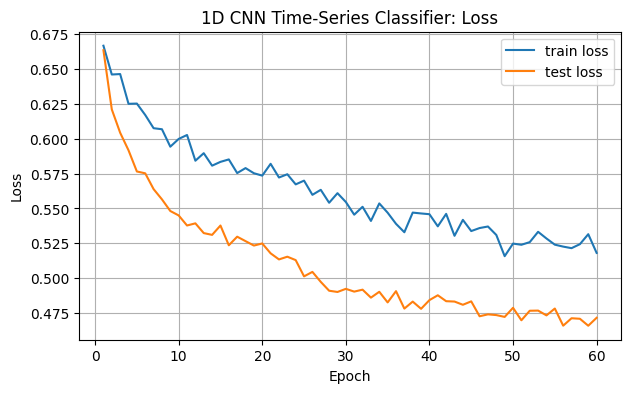

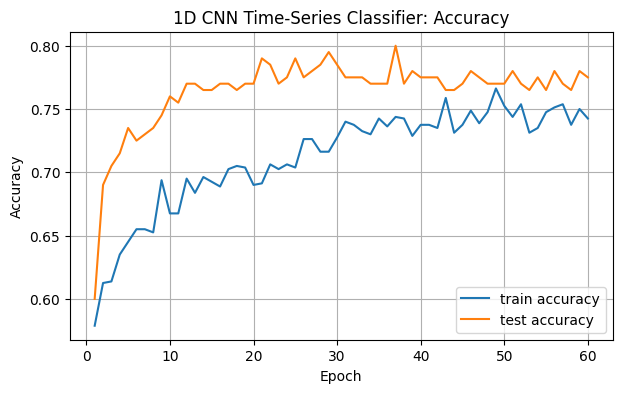

In [18]:
# =====================================================================
# 3. INITIALIZE AND TRAIN THE MODEL
# =====================================================================

# Initialize the model with the correct updated demographic dimension
fusion_model = LateFusionHeartDiseaseModel(
    sequence_length=2500,
    num_classes=2,
    in_channels=12,
    demog_dim=fused_demog_dim
)

# Increase epochs past 5 (e.g., 30) so the model has room to converge
ts_history = train_classifier(
    model=fusion_model,
    train_loader=ts_train_loader,
    test_loader=ts_test_loader,
    epochs=60,
    learning_rate=1e-4
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")


## 15. Inspect Time-Series Predictions


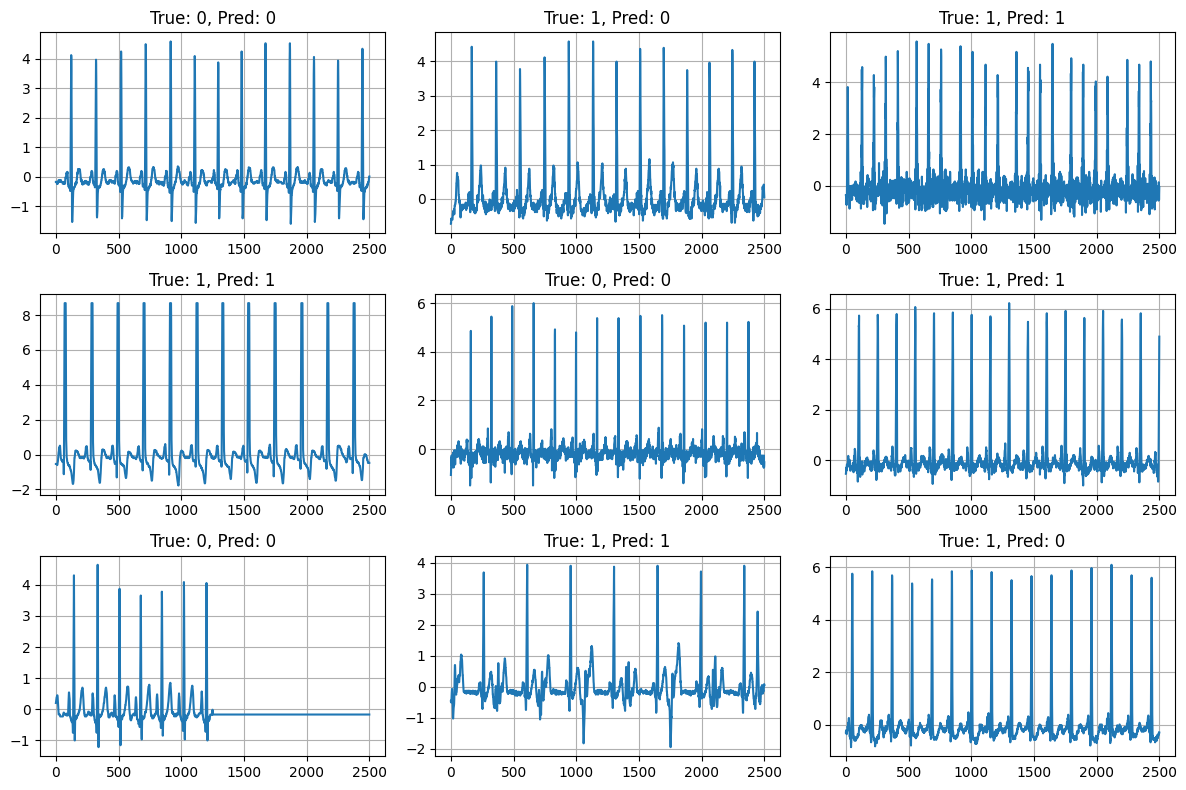

In [19]:
fusion_model.eval()

X_batch, demog_batch, y_batch = next(iter(ts_test_loader))

with torch.no_grad():
    logits = fusion_model(X_batch.to(device), demog_batch.to(device))
    predictions = torch.argmax(logits, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(X_batch[i, 0].cpu().numpy())
    plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
    plt.grid(True)

plt.tight_layout()
plt.show()


## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


In [20]:
'''
first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()
'''


'\nfirst_conv = ts_model.features[0]\nfilters = first_conv.weight.detach().cpu().numpy()\n\nplt.figure(figsize=(10, 6))\nfor i in range(filters.shape[0]):\n    plt.subplot(2, 4, i + 1)\n    plt.plot(filters[i, 0])\n    plt.title(f"Filter {i}")\n    plt.grid(True)\n\nplt.tight_layout()\nplt.show()\n'


# Summary

This notebook showed two applications of convolutional neural networks in PyTorch.

## 2D CNN for MNIST

A 2D CNN uses filters that slide across image height and width. This is useful for image data because nearby pixels contain meaningful local structure.

## 1D CNN for Time Series

A 1D CNN uses filters that slide along the time axis. This is useful for detecting short temporal patterns such as oscillations, spikes, jumps, or repeated motifs.

## Key PyTorch Ideas

The most important PyTorch components were:

- `nn.Conv2d` for image convolution,
- `nn.Conv1d` for time-series convolution,
- `nn.ReLU` for nonlinear activation,
- `nn.MaxPool2d` and `nn.MaxPool1d` for downsampling,
- `nn.Linear` for dense classification layers,
- `nn.CrossEntropyLoss` for multiclass classification,
- `loss.backward()` for automatic backpropagation,
- `torch.optim.Adam` for parameter updates.

Compared with the NumPy implementation, PyTorch makes the neural network code much shorter because it handles gradients automatically.


## 1. Setup

The code below imports standard packages. The metric implementations use NumPy and scikit-learn. The neural-network prediction helpers use PyTorch. The Bayesian negative ELBO helper assumes Pyro.

If Pyro is not installed, the Bayesian-specific cells can be skipped.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

Most metrics require two arrays:

$$
y = (y_1, \ldots, y_N)
$$

and

$$
\hat p = (\hat p_1, \ldots, \hat p_N),
$$

where \(\hat p_i\) is the predicted probability of the positive class, class 1.

For binary classification, the hard predicted class is usually

$$
\hat y_i = \mathbb{1}(\hat p_i \geq \tau),
$$

where \(\tau = 0.5\) is the default threshold.

For a neural network with two softmax outputs, we often instead define

$$
\hat y_i = \arg\max_{c \in \{0,1\}} P(y_i=c \mid x_i).
$$

These are equivalent when the positive class probability threshold is 0.5.

In [22]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

A standard neural network classifier has a single fitted set of weights, often denoted \(\theta\). The model estimates

$$
P(y \mid x, \theta).
$$

For a PyTorch model, the usual evaluation pipeline is:

1. Set the model to evaluation mode with `model.eval()`.
2. Send batches to the correct device.
3. Compute logits.
4. Convert logits to probabilities with softmax.
5. Store labels and probabilities.

The function below assumes your model returns logits of shape `[batch_size, 2]`.

In [23]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):
    """
    Collect labels and probabilities from a standard deterministic neural network.

    Args:
        model: PyTorch classifier returning logits of shape [batch_size, 2].
        data_loader: DataLoader yielding (x, y) or (x_ts, x_demo, y).
        device: torch device.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for batch in data_loader:
        if len(batch) == 3:
            X_ts_b, X_demo_b, y_b = batch
            X_ts_b = X_ts_b.to(device)
            X_demo_b = X_demo_b.to(device)
            y_b = y_b.to(device)
            logits = model(X_ts_b, X_demo_b)
        elif len(batch) == 2:
            X_b, y_b = batch
            X_b = X_b.to(device)
            y_b = y_b.to(device)
            logits = model(X_b)
        else:
            raise ValueError(f"Unexpected number of items in batch: {len(batch)}")

        probs = F.softmax(logits, dim=-1)

        all_y.append(y_b.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 4. Collecting predictions from a Bayesian neural network

A Bayesian neural network places a prior distribution over weights:

$$
p(\theta)
$$

and uses the data to form a posterior distribution:

$$
p(\theta \mid \mathcal{D}).
$$

The posterior predictive distribution averages over uncertainty in the weights:

$$
p(y^* \mid x^*, \mathcal{D}) = \int p(y^* \mid x^*, \theta) p(\theta \mid \mathcal{D}) \, d\theta.
$$

In practice, this integral is usually approximated with Monte Carlo samples:

$$
p(y^* \mid x^*, \mathcal{D}) \approx \frac{1}{S} \sum_{s=1}^S p(y^* \mid x^*, \theta^{(s)}),
$$

where

$$
\theta^{(s)} \sim q(\theta)
$$

and \(q(\theta)\) is the variational posterior learned by the guide.

For your Pyro model, the helper below assumes you already have a function named `predict_proba_bayesian(model, guide, x, num_samples)` that returns posterior-averaged probabilities of shape `[batch_size, 2]`.

In [24]:
@torch.no_grad()
def collect_predictions_bayesian_nn(model, guide, data_loader, device, num_samples=100):
    """
    Collect labels and posterior predictive probabilities from a Bayesian neural network.

    This assumes a helper function exists:
        predict_proba_bayesian(model, guide, x, num_samples)

    Args:
        model: PyroModule Bayesian classifier.
        guide: Pyro guide, such as AutoDiagonalNormal(model).
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        num_samples: Number of posterior samples used for prediction.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        mean_probs = predict_proba_bayesian(
            model=model,
            guide=guide,
            x=x,
            num_samples=num_samples,
        )

        all_y.append(y.detach().cpu())
        all_probs.append(mean_probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

For binary classification, many metrics are built from the confusion matrix.

| Quantity | Meaning |
|---|---|
| TP | True positives: true class 1 and predicted class 1 |
| TN | True negatives: true class 0 and predicted class 0 |
| FP | False positives: true class 0 but predicted class 1 |
| FN | False negatives: true class 1 but predicted class 0 |

The confusion matrix is usually written as:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

In [25]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

Accuracy is the fraction of all examples classified correctly:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}.
$$

Interpretation:

- Accuracy ranges from 0 to 1.
- Higher is better.
- It is easy to understand.
- It can be misleading when classes are imbalanced.

For example, if 90% of patients are class 0, a classifier that always predicts class 0 gets 90% accuracy but has zero sensitivity for class 1.

In [26]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

Sensitivity is also called recall or the true positive rate:

$$
\text{Sensitivity} = \frac{TP}{TP + FN}.
$$

It answers:

> Among truly positive cases, what fraction did the model detect?

Specificity is the true negative rate:

$$
\text{Specificity} = \frac{TN}{TN + FP}.
$$

It answers:

> Among truly negative cases, what fraction did the model correctly rule out?

Interpretation in a medical classifier:

- High sensitivity means few missed positive cases.
- High specificity means few false alarms.
- The preferred balance depends on the clinical cost of false negatives versus false positives.

In [27]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

Balanced accuracy averages sensitivity and specificity:

$$
\text{Balanced Accuracy} = \frac{1}{2}
\left(
\frac{TP}{TP+FN} + \frac{TN}{TN+FP}
\right).
$$

Interpretation:

- Balanced accuracy ranges from 0 to 1.
- Higher is better.
- It is more informative than ordinary accuracy when the classes are imbalanced.
- A classifier that performs well only on the majority class will have poor balanced accuracy.

In [28]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

The receiver operating characteristic curve plots:

$$
\text{TPR}(\tau) = \frac{TP(\tau)}{TP(\tau)+FN(\tau)}
$$

against

$$
\text{FPR}(\tau) = \frac{FP(\tau)}{FP(\tau)+TN(\tau)}
$$

as the classification threshold \(\tau\) varies from 0 to 1.

The AUROC is the area under this curve.

Interpretation:

- AUROC ranges from 0 to 1.
- 0.5 means random ranking.
- 1.0 means perfect ranking.
- AUROC measures how well the model ranks positives above negatives.
- AUROC does not depend on a single classification threshold.

A useful probabilistic interpretation is:

$$
\text{AUROC} = P(\hat p_{\text{positive}} > \hat p_{\text{negative}}),
$$

up to handling of ties.

AUROC can look optimistic under strong class imbalance, so it is often useful to also report AUPRC.

In [29]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

The precision-recall curve plots precision against recall as the threshold varies.

Precision is:

$$
\text{Precision} = \frac{TP}{TP+FP}.
$$

Recall is the same as sensitivity:

$$
\text{Recall} = \frac{TP}{TP+FN}.
$$

The AUPRC is the area under the precision-recall curve.

Interpretation:

- AUPRC ranges from 0 to 1.
- Higher is better.
- It is especially useful when the positive class is rare.
- The baseline AUPRC is approximately the prevalence of the positive class:

$$
\text{Baseline AUPRC} \approx P(y=1).
$$

For example, if only 10% of examples are positive, an AUPRC of 0.40 may be much better than it first appears.

In [30]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

For binary classification, if \(\hat p_i = P(y_i=1 \mid x_i)\), the negative log likelihood is:

$$
\text{NLL} = -\frac{1}{N}\sum_{i=1}^{N}
\left[
    y_i \log(\hat p_i) + (1-y_i)\log(1-\hat p_i)
\right].
$$

This is the same as binary cross-entropy.

For a two-class softmax classifier, it can also be written as:

$$
\text{NLL} = -\frac{1}{N}\sum_{i=1}^{N}\log P(y_i \mid x_i).
$$

Interpretation:

- Lower is better.
- NLL rewards assigning high probability to the correct class.
- NLL penalizes confident wrong predictions very heavily.
- Unlike accuracy, NLL uses the actual predicted probabilities.

For a Bayesian neural network, NLL should be calculated using the posterior predictive probability:

$$
P(y_i \mid x_i, \mathcal{D}) \approx \frac{1}{S}\sum_{s=1}^{S} P(y_i \mid x_i, \theta^{(s)}).
$$

In [31]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

For binary classification, the Brier score is the mean squared error of the predicted probability:

$$
\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(\hat p_i - y_i)^2.
$$

Interpretation:

- Lower is better.
- A perfect classifier has Brier score 0.
- Brier score measures both discrimination and calibration.
- It is less harsh than NLL for very confident wrong predictions.

Examples:

- If \(y=1\) and $$\hat p=0.9$$, contribution is $$(0.9-1)^2=0.01$$.
- If \(y=1\) and $$\hat p=0.1$$, contribution is $$(0.1-1)^2=0.81$$.

In [32]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

Calibration asks whether predicted probabilities match observed frequencies.

A well-calibrated model should satisfy:

$$
P(y=1 \mid \hat p = 0.8) \approx 0.8.
$$

Expected calibration error groups predictions into bins and compares accuracy to confidence in each bin.

For bin \(B_m\), define:

$$
\text{acc}(B_m) = \frac{1}{|B_m|}\sum_{i \in B_m}\mathbb{1}(\hat y_i = y_i),
$$

and

$$
\text{conf}(B_m) = \frac{1}{|B_m|}\sum_{i \in B_m}\max_c P(y_i=c \mid x_i).
$$

Then:

$$
\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N}
\left|\text{acc}(B_m) - \text{conf}(B_m)\right|.
$$

Interpretation:

- ECE is usually between 0 and 1.
- Lower is better.
- ECE near 0 means confidence agrees with empirical accuracy.
- ECE depends on the number of bins.
- ECE is not a proper scoring rule, but it is easy to interpret.

For Bayesian neural networks, ECE should be computed from posterior predictive probabilities, not from a single posterior sample.

In [33]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

The evidence lower bound is central to variational Bayesian inference.

For Bayesian neural network weights $$\theta$$, likelihood $$p(\mathcal{D}\mid\theta)$$, prior $$p(\theta)$$, and variational posterior \(q_\phi(\theta)\), the ELBO is:

$$
\mathcal{L}(\phi) =
\mathbb{E}_{q_\phi(\theta)}\left[\log p(\mathcal{D}\mid\theta)\right]
-
\mathrm{KL}\left(q_\phi(\theta) \;\|\; p(\theta)\right).
$$

Training usually minimizes the negative ELBO:

$$
-\mathcal{L}(\phi)
=
-\mathbb{E}_{q_\phi(\theta)}\left[\log p(\mathcal{D}\mid\theta)\right]
+
\mathrm{KL}\left(q_\phi(\theta) \;\|\; p(\theta)\right).
$$

Interpretation:

- Lower negative ELBO is better.
- The first term rewards good predictive fit to the labels.
- The KL term penalizes posteriors that move far from the prior.
- Negative ELBO is not the same as accuracy.
- A model can improve negative ELBO while accuracy stays flat or temporarily decreases.

For a standard deterministic neural network, there is no posterior over weights, so ELBO is not usually defined. The closest common objective is negative log likelihood or cross-entropy, possibly with an L2/weight-decay penalty:

$$
\text{Loss}(\theta) = -\sum_i \log p(y_i \mid x_i, \theta) + \lambda \|\theta\|_2^2.
$$

In [34]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):
    """
    Estimate negative ELBO per example for a Pyro Bayesian neural network.

    Args:
        model: Pyro model with forward(x, y=None, dataset_size=None).
        guide: Pyro guide.
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        dataset_size: Optional size used for minibatch scaling. If None, each batch
                      uses its own batch size, which is often appropriate for a
                      held-out evaluation estimate.

    Returns:
        negative_elbo_per_example: scalar float
    """
    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

The helper below calculates the main classification metrics from labels and probabilities.

It works for both standard and Bayesian classifiers because once predictions have been collected, the metrics are identical. The only difference is how the probabilities are obtained:

- Standard neural network: one forward pass with fixed weights.
- Bayesian neural network: posterior-predictive average over multiple sampled weights.

In [35]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier

Use this wrapper when you have a deterministic PyTorch classifier.

In [36]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 17. Wrapper for a Bayesian neural network classifier

Use this wrapper when you have a Pyro Bayesian neural network and guide.

The metrics are computed from posterior predictive probabilities.

The negative ELBO is computed separately using Pyro's `Trace_ELBO`.

In [37]:
def evaluate_bayesian_nn_classifier(model, guide, data_loader, device, num_samples=100, n_bins=10, dataset_size=None):
    y_true, probs, y_pred = collect_predictions_bayesian_nn(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        num_samples=num_samples,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["negative_elbo_per_example"] = estimate_negative_elbo_per_example_pyro(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        dataset_size=dataset_size,
    )

    metrics["num_posterior_prediction_samples"] = num_samples

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

The next cell creates a small artificial example so that the metric code can be tested without needing a trained model.

In [41]:
y_true_test, probs, y_pred = collect_predictions_standard_nn(
    model=fusion_model,
    data_loader=ts_test_loader,
    device=device,
)

metrics_demo = calculate_binary_classification_metrics(
    y_true=y_true_test,
    probs=probs,
    n_bins=10,
)

pd.DataFrame([metrics_demo]).T.rename(columns={0: "value"})

,value
accuracy,0.775000
balanced_accuracy,0.775000
auroc,0.878200
auprc,0.876348
sensitivity,0.660000
specificity,0.890000
negative_log_likelihood,0.471560
brier_score,0.153390
expected_calibration_error,0.071725
tn,89.000000
